# Design of H-Profiles acc. to Neumann Regarding Lateral Flow

In [1]:
import ezdxf  # for DXF import
import shapely  # for planar geometric operations
import shapely.geometry as sg  # geometric objects
import ezdxf_shapely  # for conversion from DXF to shapely geometry
import numpy as np  # array computations
import math  # mathematical constants
from ipywidgets import interact  # interactive plots
from plot_helper import plot_geom, plot_geoms # module in local directory with helpers to plot geometries
from dataclasses import dataclass
import pandas as pd
import plotly.express as px

## Construct Parametrized H-Beam Cross-Sections

Define a class representing a H or I beam profile constructed by size parameters.

![](dxf/h_beam.png)

In [2]:
@dataclass()
class HBeam:
    w:float 
    s:float
    au:float
    al:float
    bu:float
    bl:float
    hu:float
    hl:float
    
    def __post_init__(self):
        self.coordinates = np.array([
            (self.w / 2, -self.s / 2 - self.hl),
            (self.w / 2, self.s / 2 + self.hu),
            (self.w / 2 - self.au, self.s / 2 + self.hu),
            (self.w / 2 - self.bu, self.s / 2),
            (-self.w / 2 + self.bu, self.s / 2),
            (-self.w / 2 + self.au, self.s / 2 + self.hu),
            (-self.w / 2, self.s / 2 + self.hu),
            (-self.w / 2, -self.s / 2 - self.hl),
            (-self.w / 2 + self.al, -self.s / 2 - self.hl),
            (-self.w / 2 + self.bl, -self.s / 2),
            (self.w / 2 - self.bl, -self.s / 2),
            (self.w / 2 - self.al, -self.s / 2 - self.hl),
        ])
        
        self.cross_section = sg.Polygon(self.coordinates).simplify(0)

Plot a beam with interactive parameters to play around with the measures.

In [3]:
beam = None

@interact
def draw_h_beam_interactively(w=100, s=20, au=10, al=10, bu=20, bl=20, hu=30, hl=30):
    global beam
    beam = HBeam(w,s,au,al,bu,bl,hu,hl)
    line = sg.LineString([(0, -50), (0, 50)])
    return plot_geoms([beam.cross_section])

interactive(children=(IntSlider(value=100, description='w', max=300, min=-100), IntSlider(value=20, descriptio…

## Division in Partial Cross-Sections acc. to Neumann

Define a class cutting the beam cross-section into devisions by the method of Neumann.

In [4]:
class NeumannDivision:
    def __init__(self, beam: HBeam):
        self.full = beam.cross_section
        self.upper_flange = shapely.clip_by_rect(self.full, -np.inf, beam.s / 2, np.inf, np.inf)
        self.lower_flange = shapely.clip_by_rect(self.full, -np.inf, -np.inf, np.inf, -beam.s / 2)
        left_split_line = sg.LineString([beam.coordinates[4], beam.coordinates[9]])
        right_split_line = sg.LineString([beam.coordinates[3], beam.coordinates[10]])

        if not self.upper_flange.is_empty and not self.lower_flange.is_empty:
            web = shapely.clip_by_rect(self.full, -np.inf, -beam.s / 2, np.inf, beam.s / 2)
            left_gore, web = shapely.ops.split(web, left_split_line).geoms
            web, right_gore = shapely.ops.split(web, right_split_line).geoms
    
            self.gore = shapely.unary_union([left_gore, right_gore])
            self.web = web
        else:
            self.gore = sg.Polygon()
            self.web = self.full

        self.parts = [self.upper_flange, self.lower_flange, self.web, self.gore]
        self.part_areas = np.array([p.area for p in self.parts])

In [5]:
division = NeumannDivision(beam)
plot_geoms([division.upper_flange, division.lower_flange, division.web, division.gore], names=["upper flange", "lower flange", "web", "gore"])

## Calculate Theoretical Lateral Flows

In [6]:
calibration = pd.read_csv("I50_calibration_Neumann.csv")
calibration

,open,w,s,au,al,bu,bl,hu,hl
0,upper,388.0,100.0,101.0,105.0,154.0,160.0,95.00,93.50
1,lower,404.0,73.0,88.6,78.5,132.0,123.0,95.50,103.50
2,upper,419.0,54.5,67.1,69.5,102.5,107.0,101.75,100.75
3,lower,433.0,42.0,60.0,53.0,90.0,83.6,97.50,105.00
4,upper,440.0,33.2,46.1,47.8,70.7,74.0,99.40,99.40
5,lower,458.0,27.2,42.0,37.0,63.1,58.8,94.40,101.40
6,upper,469.0,23.0,32.8,34.0,50.5,53.0,95.50,95.50
7,lower,479.0,20.2,30.3,26.8,46.0,42.8,89.90,95.70
8,upper,488.0,18.4,24.1,25.0,37.4,39.2,90.10,90.00
9,lower,496.0,17.3,22.7,20.0,34.6,32.2,85.05,90.15


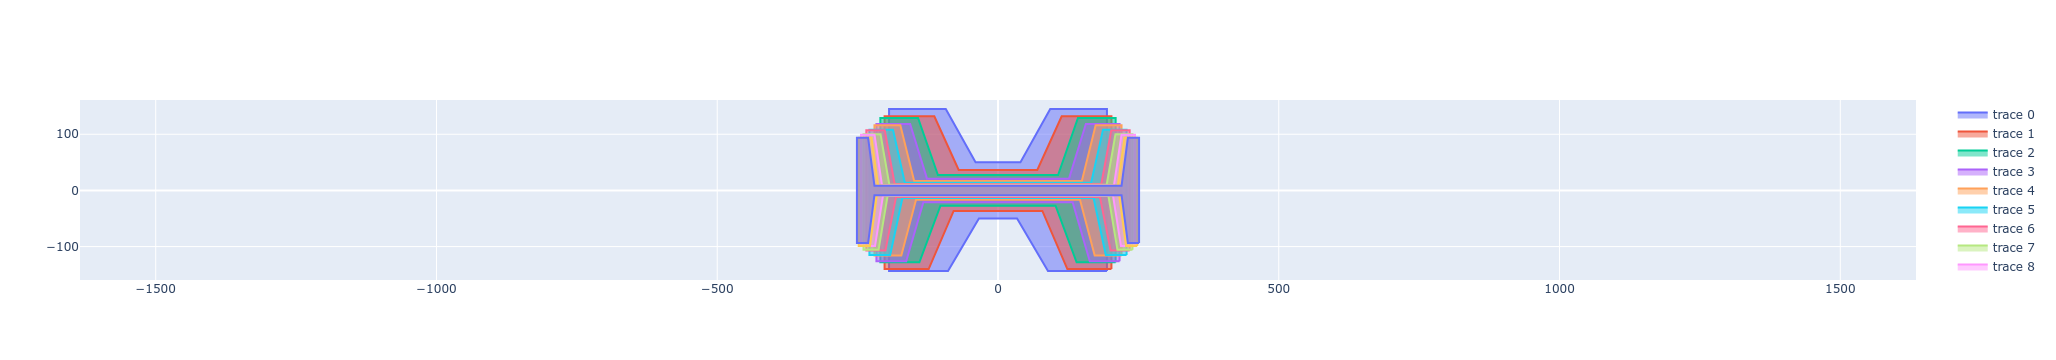

In [7]:
beams = [HBeam(c.w, c.s, c.au,c.al,c.bu,c.bl,c.hu,c.hl) for c in calibration.itertuples(index=False)]
plot_geoms([b.cross_section for b in beams])

In [8]:
divisions = [NeumannDivision(b) for b in beams]

In [9]:
areas = pd.DataFrame([dict(
    full=d.full.area,
    upper_flange=d.upper_flange.area,
    lower_flange=d.lower_flange.area,
    gore=d.gore.area,
    web=d.web.area,
) for d in divisions])
areas["open"] = areas.upper_flange.where(calibration.open == "upper", areas.lower_flange)
areas["closed"] = areas.upper_flange.where(calibration.open == "lower", areas.lower_flange)
areas

,full,upper_flange,lower_flange,gore,web,open,closed
0,87802.500,24225.000,24777.500,31400.00,7400.00,24225.00,24777.500
1,71414.550,21067.300,20855.250,18615.00,10877.00,20855.25,21067.300
2,57874.675,17256.800,17782.375,11417.75,11417.75,17256.80,17782.375
3,47154.000,14625.000,14343.000,7291.20,10894.80,14343.00,14625.000
4,38324.840,11609.920,12106.920,4804.04,9803.96,11609.92,12106.920
5,32093.160,9921.440,9714.120,3315.68,9141.92,9714.12,9921.440
6,27050.650,7955.150,8308.500,2380.50,8406.50,7955.15,8308.500
7,23195.890,6859.370,6660.720,1793.76,7882.04,6660.72,6859.370
8,20298.350,5541.150,5778.000,1409.44,7569.76,5541.15,5778.000
9,18159.995,4873.365,4705.830,1155.64,7425.16,4705.83,4873.365


In [10]:
elongations = areas.rolling(2).apply(lambda pair: pair.iloc[0] / pair.iloc[1])
elongations["open"] = elongations.upper_flange.where(calibration.open == "upper", elongations.lower_flange)
elongations["closed"] = elongations.upper_flange.where(calibration.open == "lower", elongations.lower_flange)
elongations

,full,upper_flange,lower_flange,gore,web,open,closed
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.229476,1.149886,1.188070,1.686812,0.680335,1.188070,1.149886
2,1.233952,1.220812,1.172805,1.630356,0.952640,1.220812,1.172805
3,1.227355,1.179952,1.239795,1.565963,1.048000,1.239795,1.179952
4,1.230377,1.259699,1.184694,1.517723,1.111265,1.259699,1.184694
5,1.194175,1.170185,1.246322,1.448885,1.072418,1.246322,1.170185
6,1.186410,1.247172,1.169179,1.392850,1.087482,1.247172,1.169179
7,1.166183,1.159749,1.247388,1.327101,1.066539,1.247388,1.159749
8,1.142748,1.237896,1.152773,1.272676,1.041254,1.237896,1.152773
9,1.117751,1.137027,1.227839,1.219619,1.019474,1.227839,1.137027


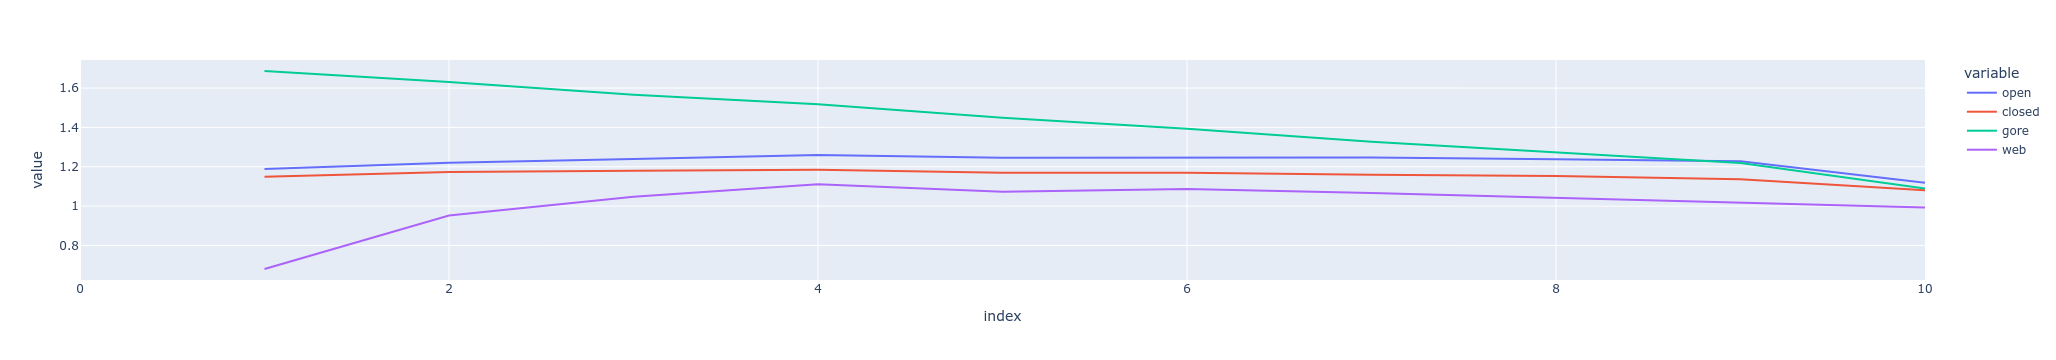

In [11]:
px.line(elongations, y=["open", "closed", "gore", "web"])

In [12]:
elongations.open > elongations.closed

0     False
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
dtype: bool

In [13]:
elongations.closed < elongations.full

0     False
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8     False
9     False
10    False
dtype: bool

In [14]:
lateral_flows = areas * (1 - elongations.div(elongations["full"], axis=0))
lateral_flows

,full,upper_flange,lower_flange,gore,web,open,closed
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,1363.789579,702.361271,-6924.328265,4858.177415,702.361271,1363.789579
2,0.0,183.764594,881.185875,-3667.930371,2602.979901,183.764594,881.185875
3,0.0,564.840747,-145.377010,-2011.531868,1592.068132,-145.377010,564.840747
4,0.0,-276.681031,449.517020,-1121.948748,949.112758,-276.681031,449.517020
5,0.0,199.311476,-424.195533,-707.215448,932.099505,-424.195533,199.311476
6,0.0,-407.423238,120.672432,-414.216980,700.967785,-407.423238,120.672432
7,0.0,37.841337,-463.805735,-247.515021,673.479419,-463.805735,37.841337
8,0.0,-461.374285,-50.688867,-160.250505,672.313658,-461.374285,-50.688867
9,0.0,-84.045641,-463.479383,-105.320785,652.845809,-463.479383,-84.045641


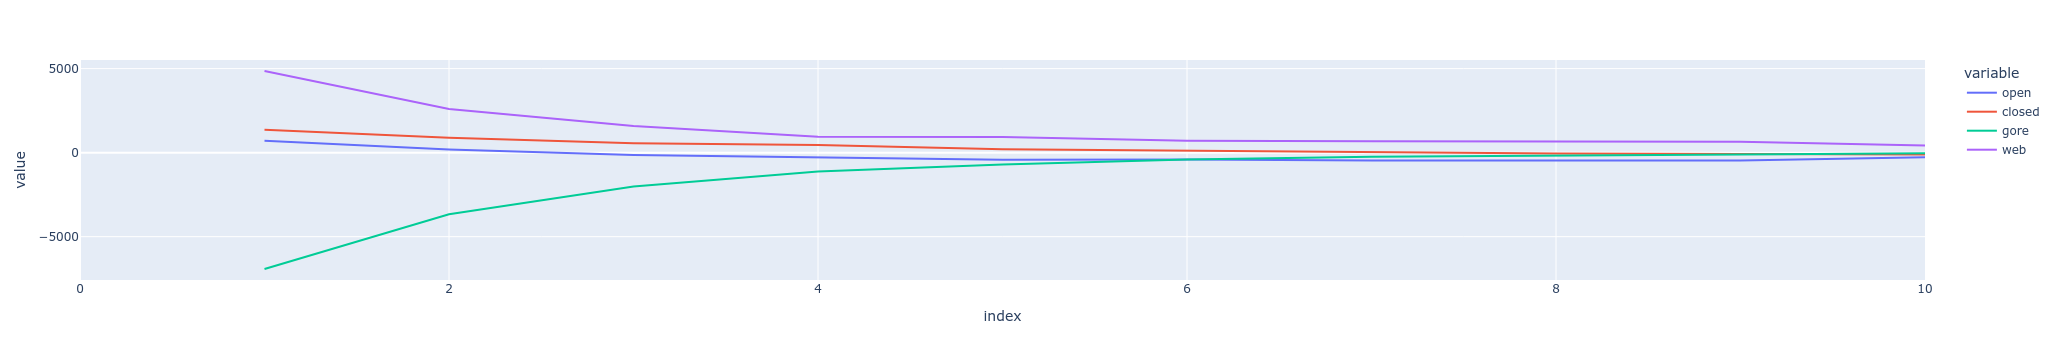

In [15]:
px.line(lateral_flows, y=["open", "closed", "gore", "web"])